# Lab 09: Probabilistic Programming with PyMC

In this lab, you will gain some hands-on experience with probabilistic programming (PP). There are many different such frameworks/languages available: Stan for C++ with many ports, pyMC for python, Turing.jl for Julia, etc. In this lab, we will work with *PyMC*.

Get started by installing PyMC using your preferred package manager, e.g. `conda install pymc` or `pip install pymc`.

In [8]:
import pymc as pm

## Part 1: Bayesian Linear Regression

Recall that linear regression is based on the equation $$Y=X\beta+\epsilon.$$ In frequentist terms, this is done by choosing (or learning) $\beta$ such that the discrepancy between $Y$ and $X\beta$ is minimized. In the Bayesian view, we express the relation as $$Y \sim \mathcal N(X\beta, \sigma^2),$$ where $\sigma^2$ corresponds to the variance of the noise term $\epsilon$. The key difference is that we assume *priors* over the parameters. Probabilistic programming is all about specifying prior distributions, the relations between them, and finally computing posterior distributions, usually done with variants of Markov Chain Monte Carlo (MCMC).

In [9]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import pymc as pm

In [10]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")

### Data Generation
Let's generate some data that roughly follows a linear function.

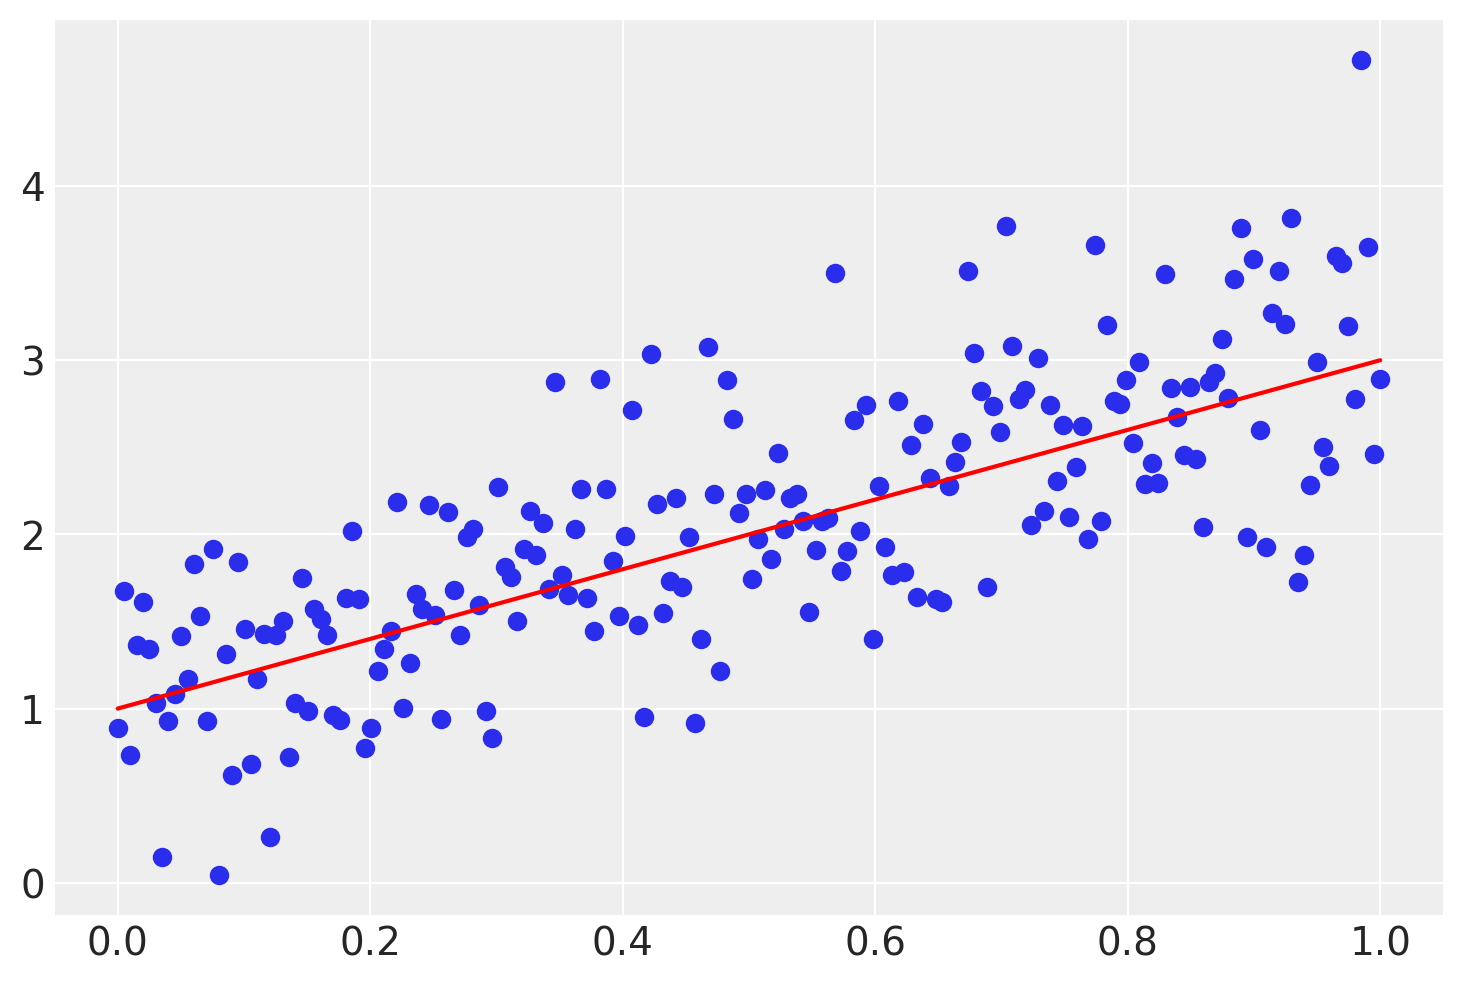

In [11]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + rng.normal(scale=0.5, size=size)

data = pd.DataFrame({"x": x, "y": y})

# Visualize the data
plt.scatter(data["x"], data["y"])
plt.plot(data["x"], true_regression_line, color="red")

### Model Estimation
In the following code block, we use pyMC to define a probabilistic model. The first three lines define the priors on $\sigma$ and $\beta$ (split into `intercept` and `slope`). The middle line defines the likelihood, in other words, how inputs and parameters relate to the output, $Y$. Finally, calling `sample(3000)` draws 3000 samples from the posterior distribution.

In [12]:
with pm.Model() as model:  # model specifications in PyMC are wrapped in a with-statement
    # Define priors
    sigma = pm.HalfCauchy("sigma", beta=10)
    intercept = pm.Normal("Intercept", 0, sigma=20)
    slope = pm.Normal("slope", 0, sigma=20)

    # Define likelihood
    likelihood = pm.Normal("y", mu=intercept + slope * x, sigma=sigma, observed=y)

    # Inference!
    # draw 3000 posterior samples using NUTS sampling
    idata = pm.sample(3000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


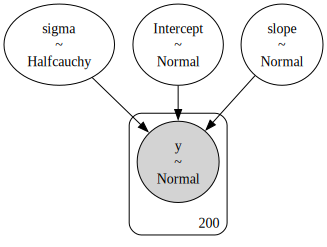

In [13]:
pm.model_to_graphviz(model)

### Model Analysis
Bayesian inference does not give us only one line of best fit (as maximum likelihood does) but a posterior distribution of plausible parameters. Let's plot the posterior distribution of our parameters and the individual samples we drew. We make use of the `arviz` library for this.

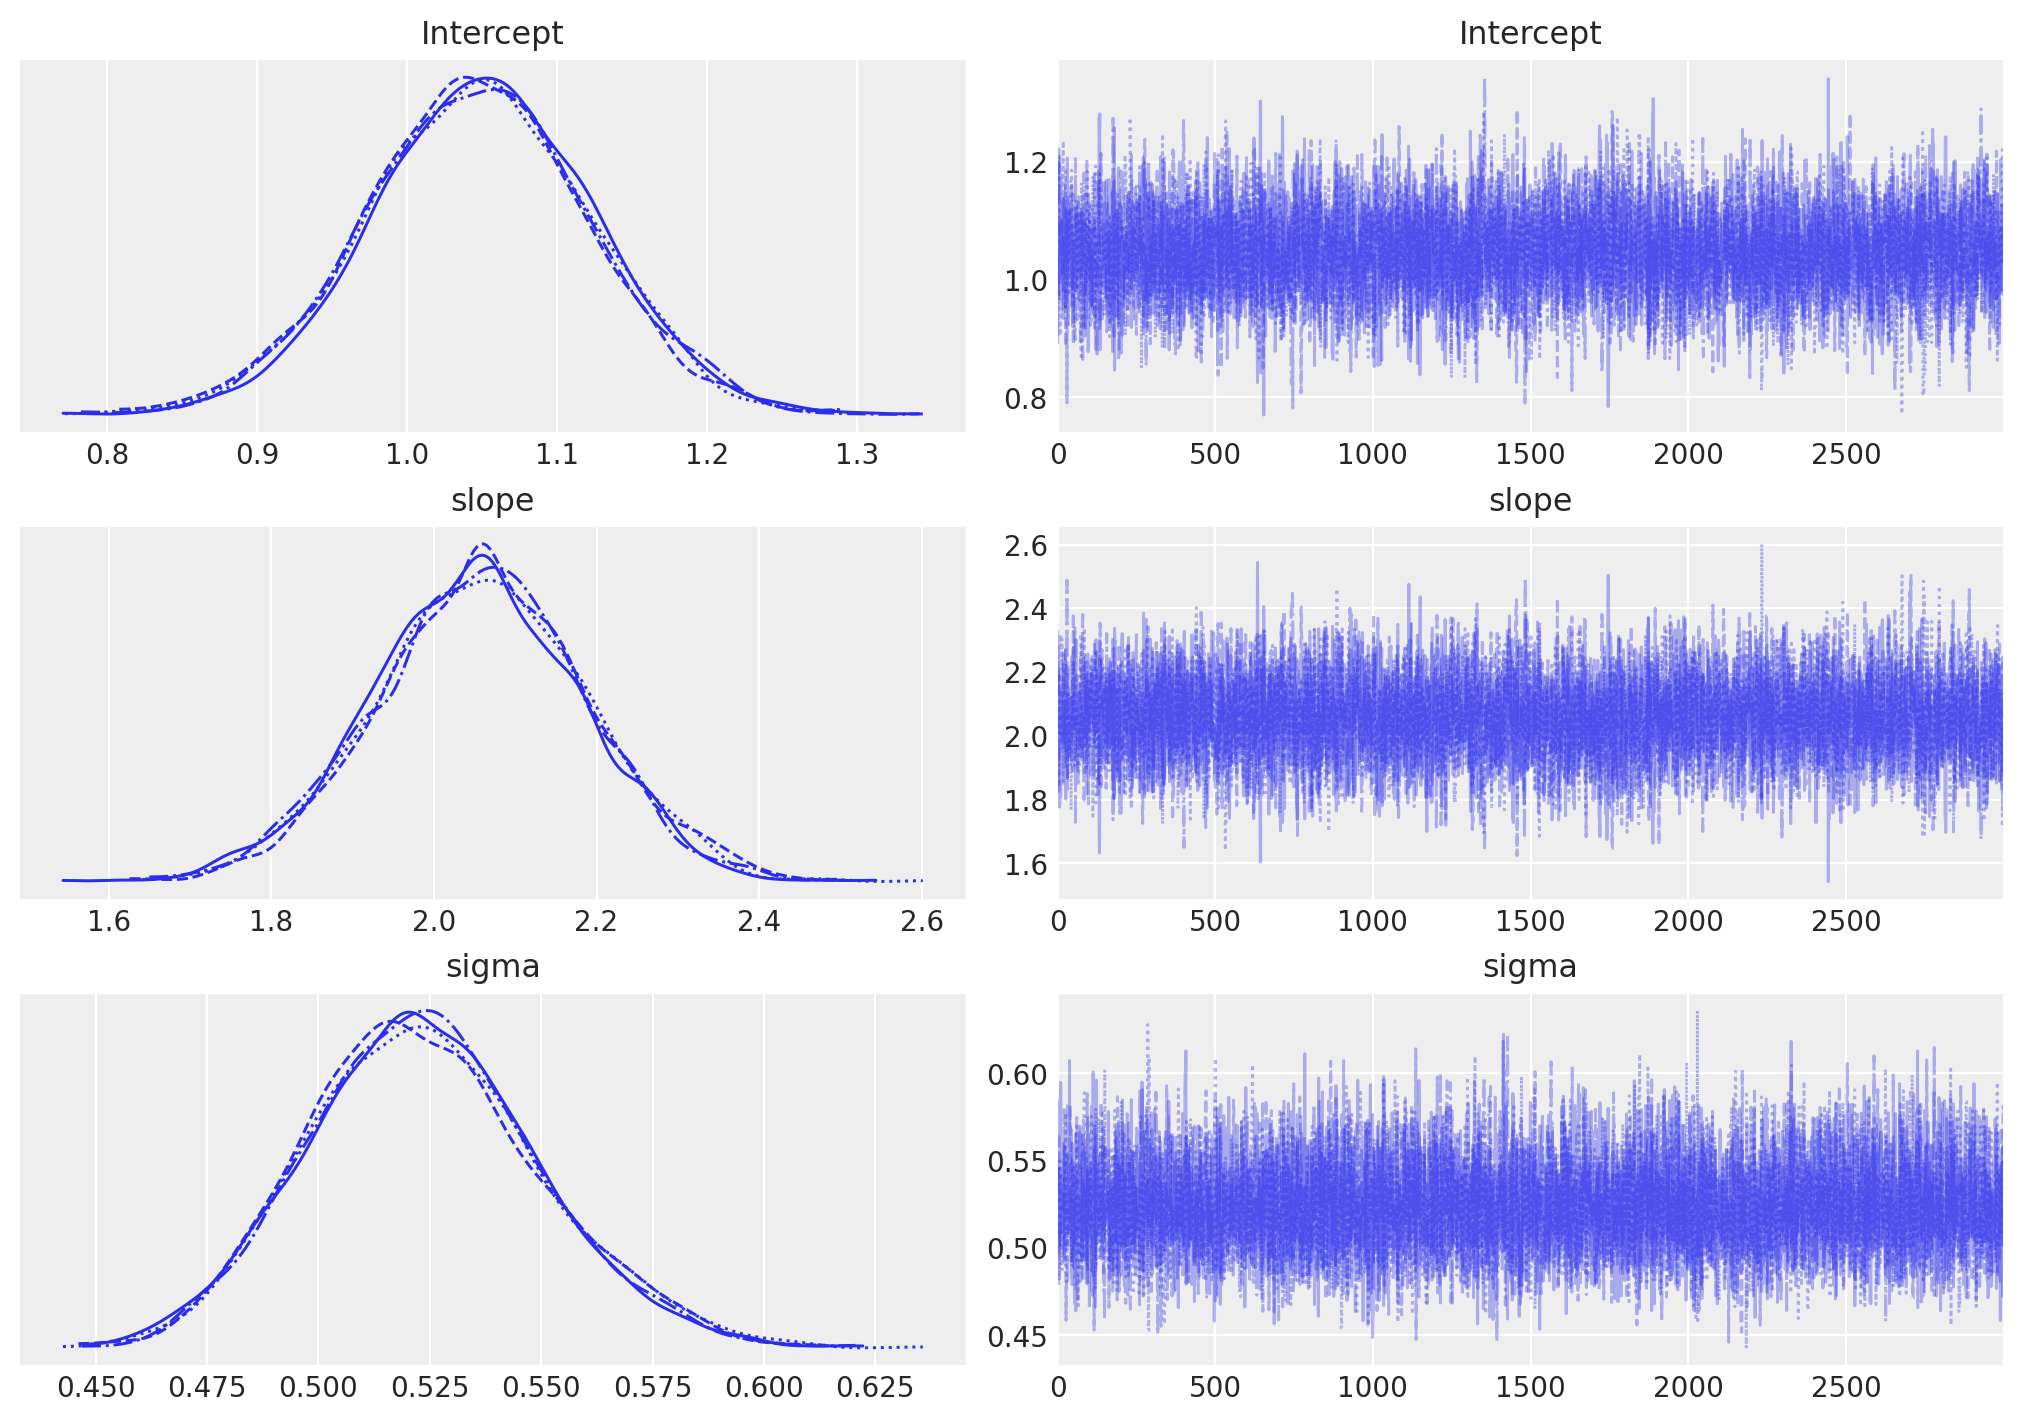

In [14]:
az.plot_trace(idata, figsize=(10, 7));

#### Question 1
Understand and interpret the plot. What do the different curves on the left mean? Why do they look similar and is it a good thing? Are the results consistent with the data generation process?

### <font color='green'><u>Solution</u></font>
The plots on the left show the posterior distribution over each parameter. Each plot contains 4 such curves, because we sampled 4 chains.
The curves in each plot looking similar is a good thing, because it indicates that the chains converge.

#### Question 2
Rather than giving us a single regression line, as we would get in classical (frequentist) linear regression, we instead have a distribution over regression lines. Re-use the data plotting code from above, but this time sample a few regression lines from the posterior distribution. Investigate the `idata` object to obtain the necessary samples.

### <font color='green'><u>Solution</u></font>

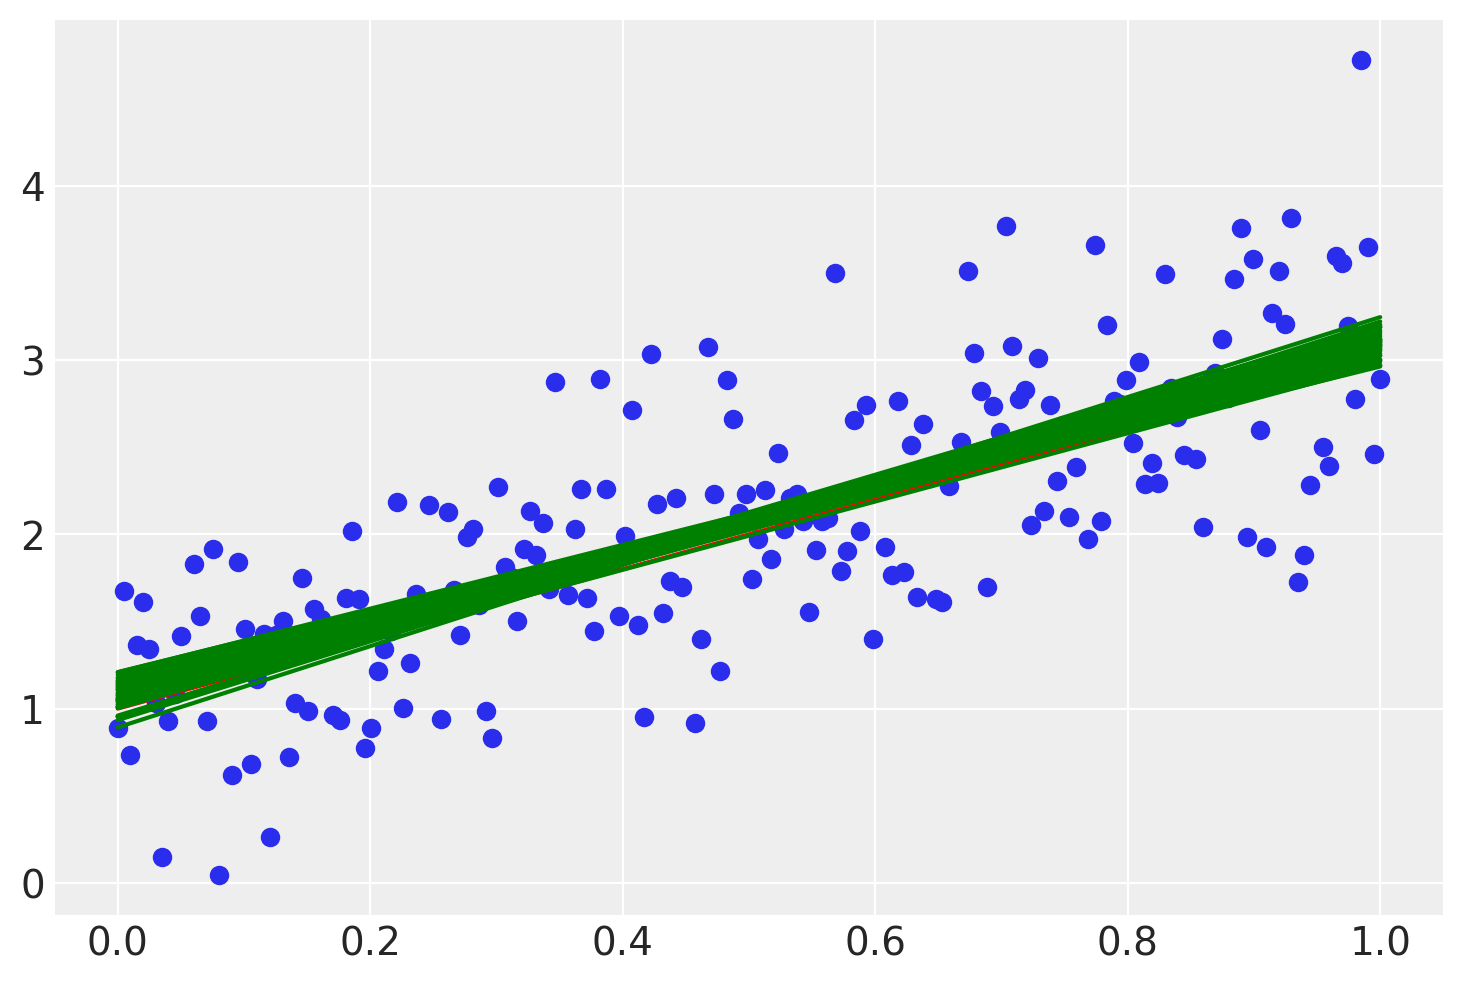

In [15]:
# Visualize the data
plt.plot()
plt.scatter(data["x"], data["y"])
plt.plot(data["x"], true_regression_line, color="red")

N = 50
# Solution
for i in range(N):
    sampled_regression_line = idata.posterior.slope[0][i].item() * x + idata.posterior.Intercept[0][i].item()
    plt.plot(data["x"], sampled_regression_line, color="green")

## Part 2: Case Study on Coal Mining Disasters

In this second part, we use real time series data of recorded coal mining disasters in the UK between 1851 to 1962. The data stems from the following paper by R. G. Jarrett: https://www.jstor.org/stable/2335266. According to the paper, incidents count as disasters, if 10 or more workers have died as a consequence.

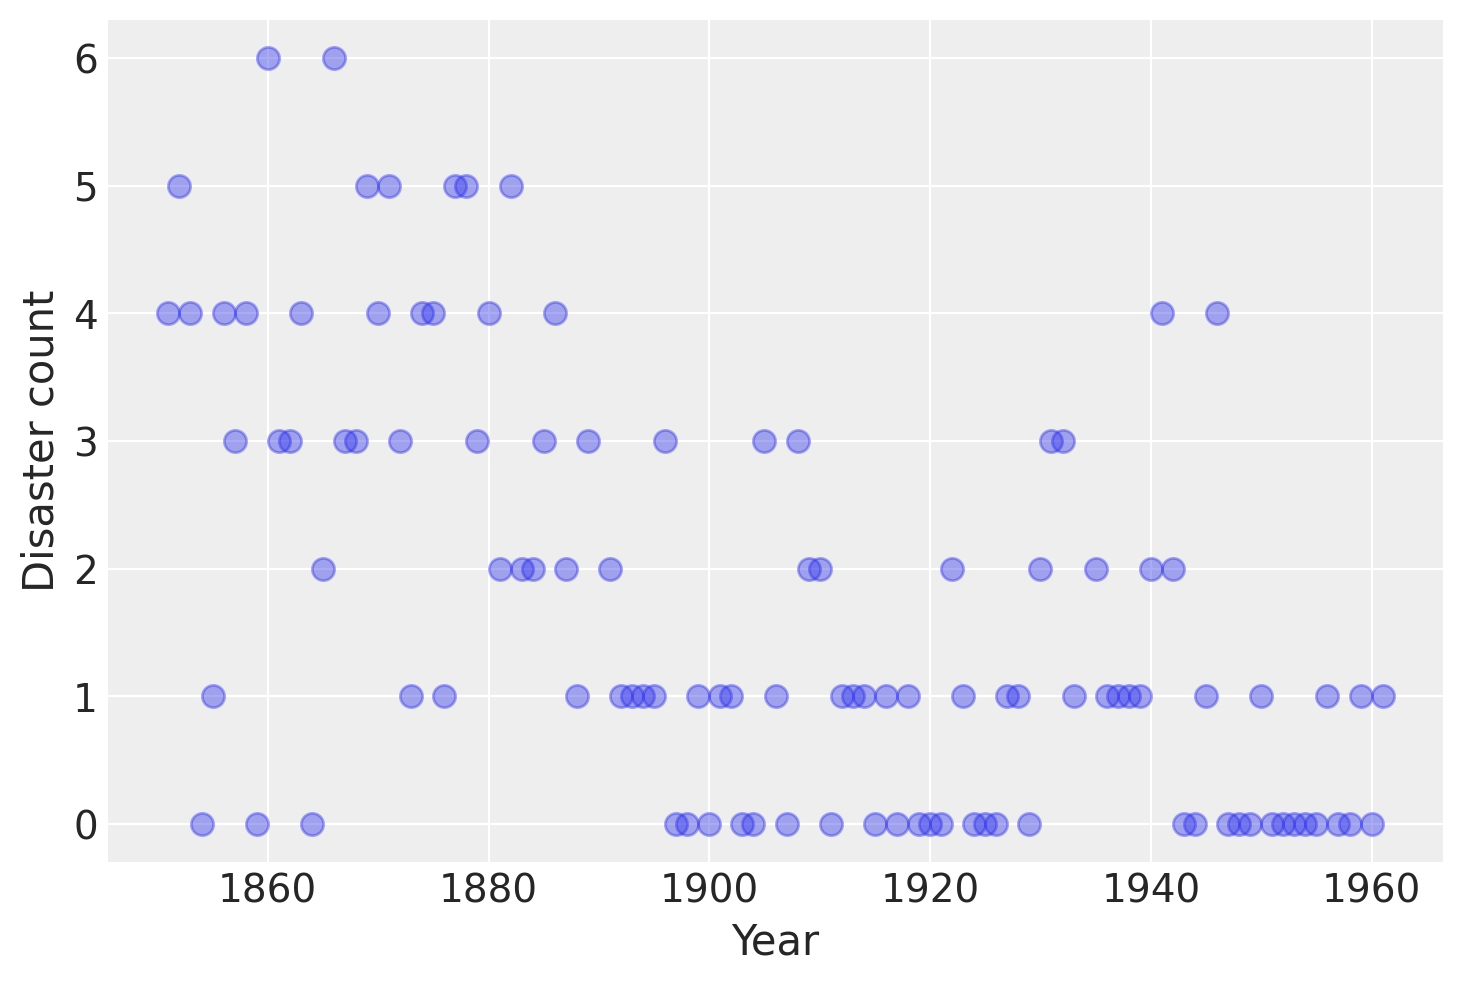

In [16]:
disaster_data = pd.Series(
    [4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
    3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
    2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,
    1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
    0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
    3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
    0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1]
)
years = np.arange(1851, 1962)

plt.plot(years, disaster_data, "o", markersize=8, alpha=0.4)
plt.ylabel("Disaster count")
plt.xlabel("Year");

Notice that two data samples are missing - a common problem when dealing with real data. The act of filling this data with suitable values is called *data imputation* and, lucky for us, is done by PyMC automatically.

### Locating the Change Point
Looking at the data with our bare eyes, we can already tell that the frequency of disasters is lower in the 1900s than in the 1800s, and that this shift must have happened close to 1900. In the following, we want to use probabilistic programming to find a better approximation of (or distribution over?) this change point.

Recall that in order to model events happening with a certain frequency, we typically use a *Poisson distribution*. In our case, we model the rate parameter as time-dependent, $r_t$. But since our goal is to find the change point, we restrict $r_t$ to have the form
$$r_t = \begin{cases} e, &\text{if }t \leq s \\ l, &\text{if }t > s \end{cases}$$
where $e$ and $l$ are the rate parameters before and after the switch point $s$, respectively. Since we have no prior knowledge, we assume the latter to be uniformly distributed between the considered years.

Concretely, our model looks as follows:
\begin{align*}
D_t &\sim \mathrm{Pois}(r_t),\\
s &\sim \mathrm{Unif}(1851, 1962), \\
e &\sim \mathrm{Exp}(1), \\
l &\sim \mathrm{Exp}(1)
\end{align*}

#### Question 3
Translate the above model into a PyMC model, similar to how we did it for the regression problem in Part 1. Use the PyMC docs to find the names of distributions ([PyMC Documentation: Distributions](https://www.pymc.io/projects/docs/en/stable/api/distributions.html)) and make use of the `pm.math.switch` function to define $r_t$ ([PyMC Documentation: pymc.math.switch](https://www.pymc.io/projects/docs/en/latest/api/generated/pymc.math.switch.html)).

For compatibility with some of the future cells, stick to the following variable names:
* `switchpoint` for $s$
* `early_rate` and `late_rate` for $e$ and $l$
* `rate` for $r_t$
* `disasters` for $D_t$

### <font color='green'><u>Solution</u></font>

In [17]:
with pm.Model() as disaster_model:
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())

    # Priors for pre- and post-switch rates number of disasters
    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)

    # Allocate appropriate Poisson rates to years before and after current
    rate = pm.math.switch(switchpoint >= years, early_rate, late_rate)

    disasters = pm.Poisson("disasters", rate, observed=disaster_data)

/Users/nagasaivegur/.pyenv/versions/3.12.3/lib/python3.12/site-packages/pymc/model/core.py:1302: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/nagasaivegur/.pyenv/versions/3.12.3/lib/python3.12/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in disasters contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Notice the warning about missing values. Missing values are handled transparently by passing a NumPy `MaskedArray` or a `DataFrame` with NaN values to the `observed` argument when creating an observed stochastic random variable. Behind the scenes, another random variable, `disasters_unobserved`, is created to model the missing values.

We can graph the proabilistic model using `graphviz`. You might have to install it first.

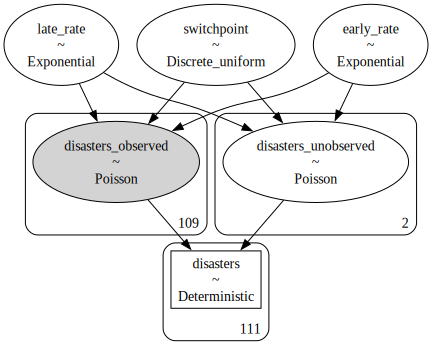

In [18]:
pm.model_to_graphviz(disaster_model)

### Sampling
Because the switch point and the missing disaster observations are discrete variables and thus have no meaningful gradient, we cannot use NUTS for sampling them. Instead, we will sample using a `Metropolis` step method, which implements adaptive Metropolis-Hastings, because it is designed to handle discrete values. PyMC automatically assigns the correct sampling algorithms.

In [19]:
with disaster_model:
    idata = pm.sample(10000)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Metropolis: [switchpoint]
>>Metropolis: [disasters_unobserved]
>NUTS: [early_rate, late_rate]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 4 seconds.


The below code uses `arviz` to show the trace plot.

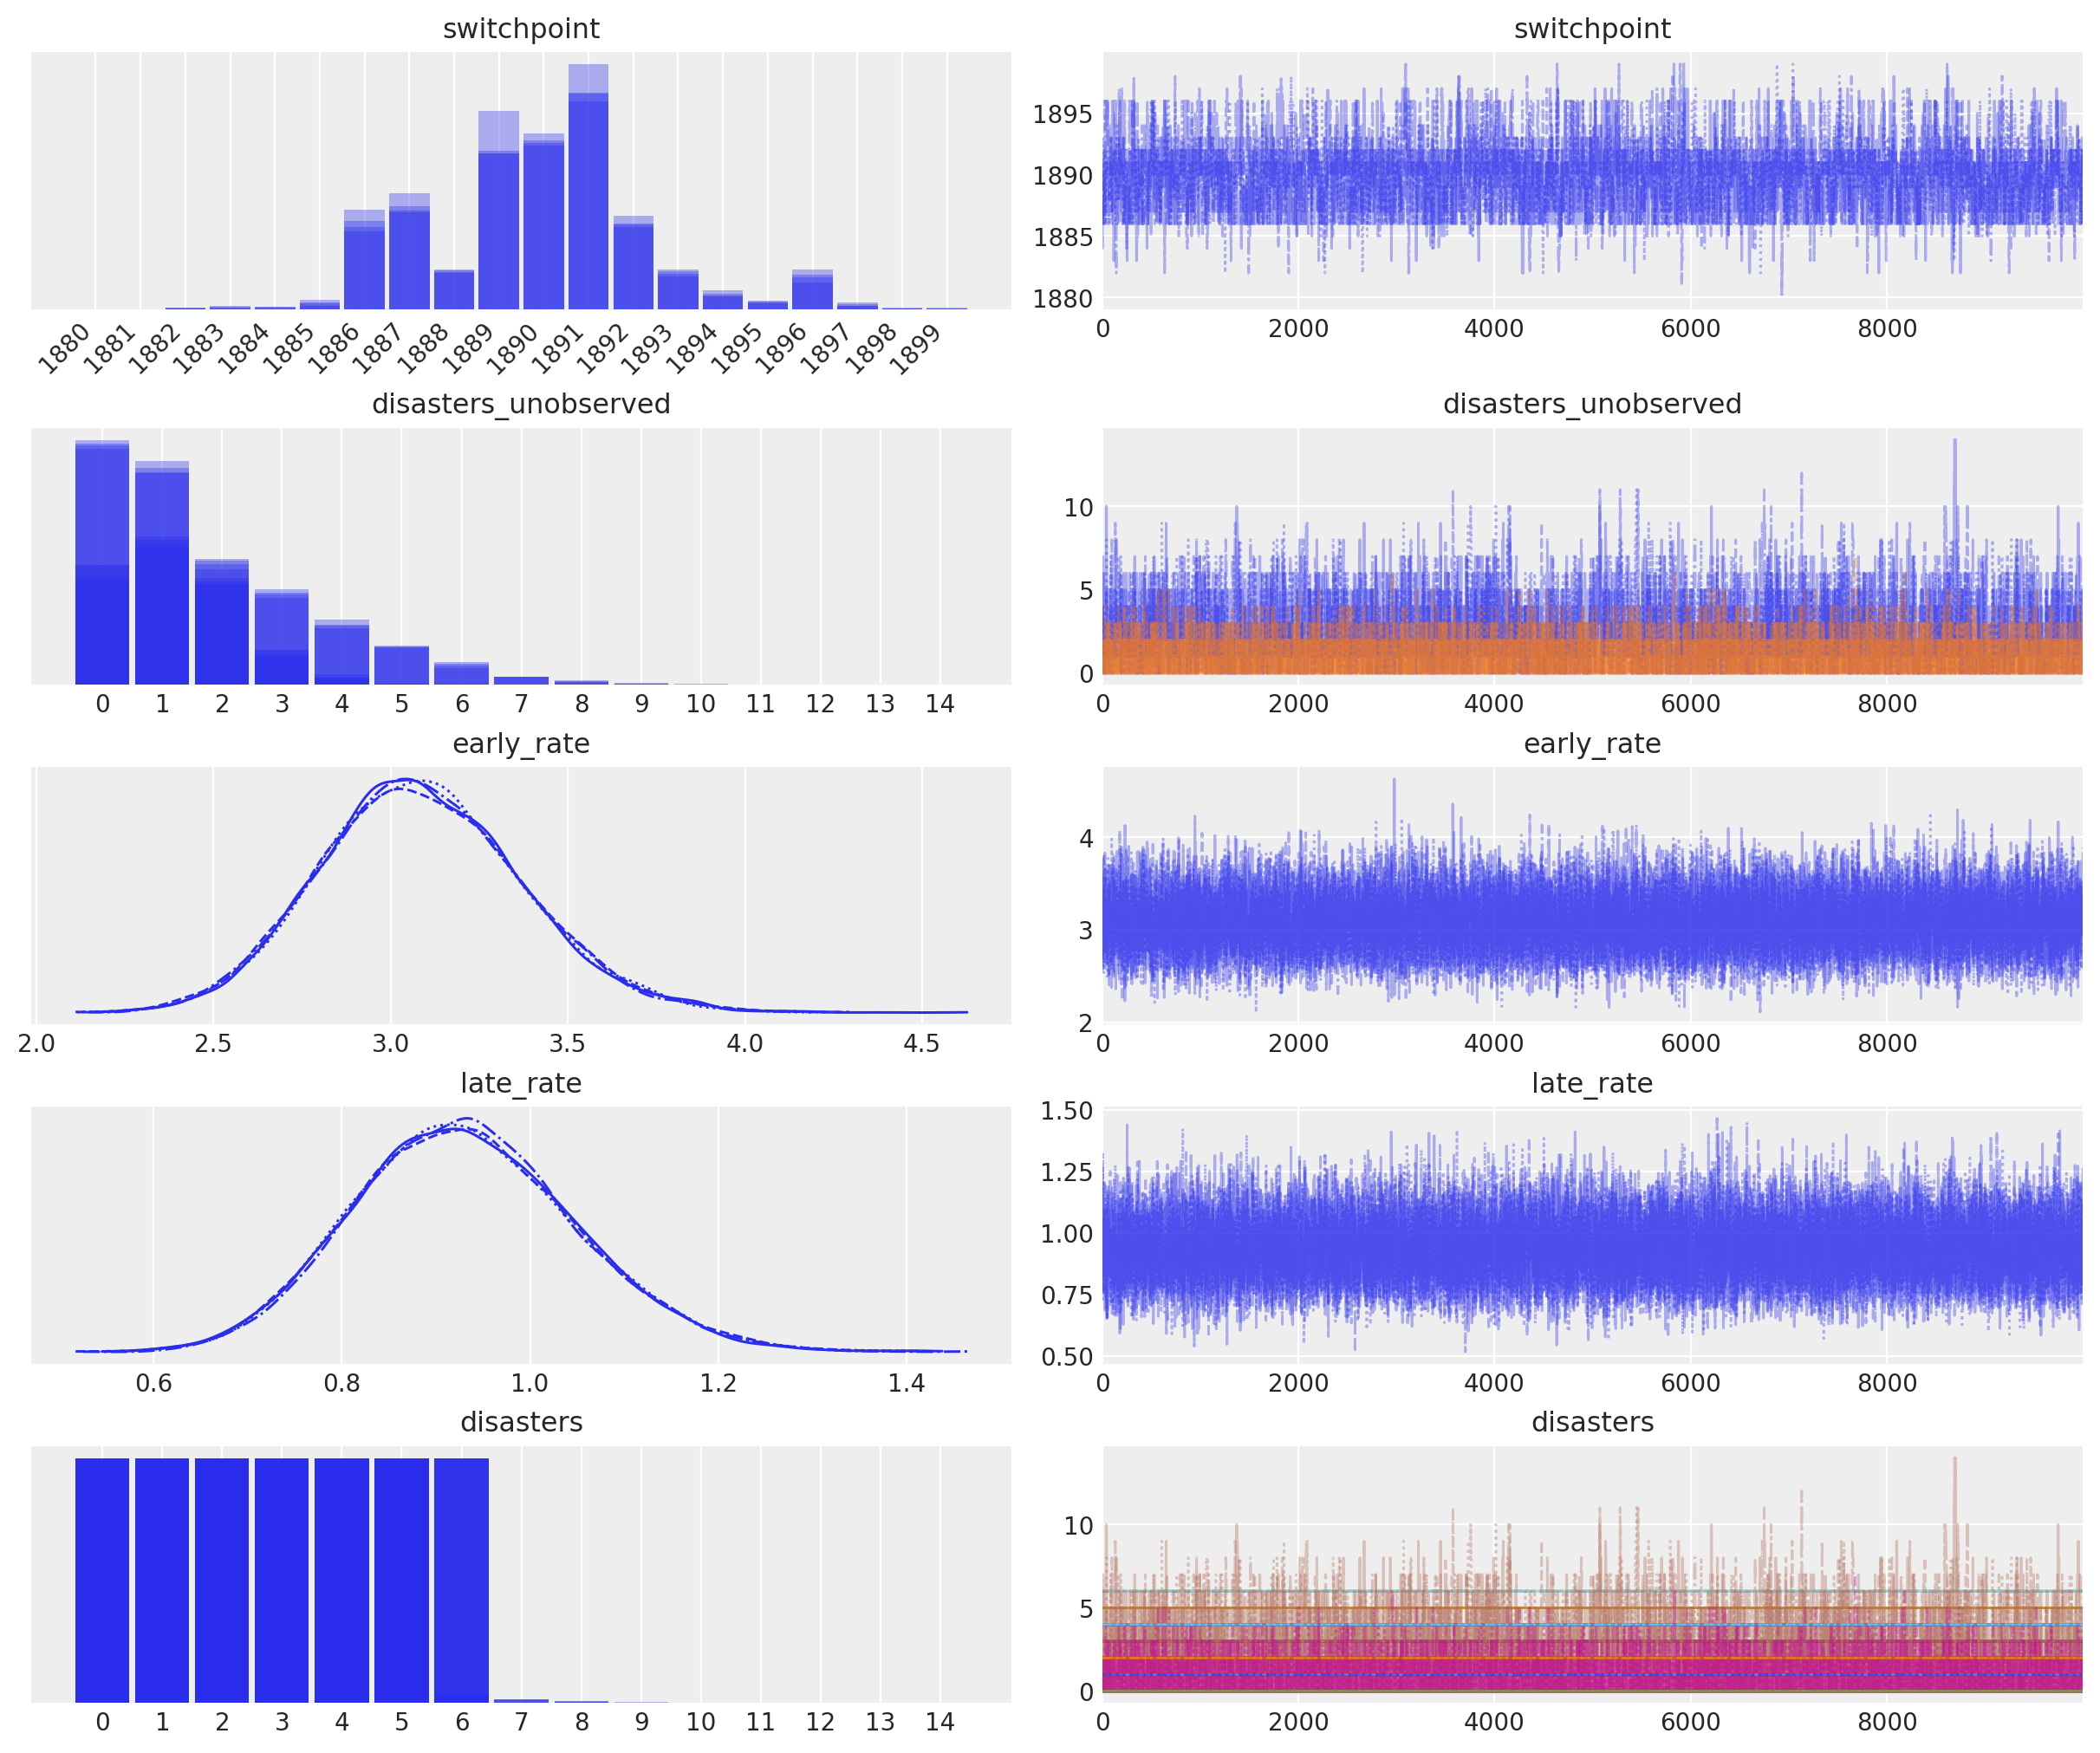

In [20]:
axes_arr = az.plot_trace(idata)
plt.draw()
for ax in axes_arr.flatten():
    if ax.get_title() == "switchpoint":
        labels = [label.get_text() for label in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha="right")
        break
plt.draw()

#### Question 4
Interpret the plot.

### <font color='green'><u>Solution</u></font>
*No "correct" solution.* Key points: the switch point appears to be *around* 1890, where the rate of disasters went from ~3.1 per year to ~0.9 per year.

The following plot shows the switch point as an orange vertical line, together with the highest density region ($\alpha = 0.94$) of the posterior as a semitransparent band. The dashed black line shows the accident rate.

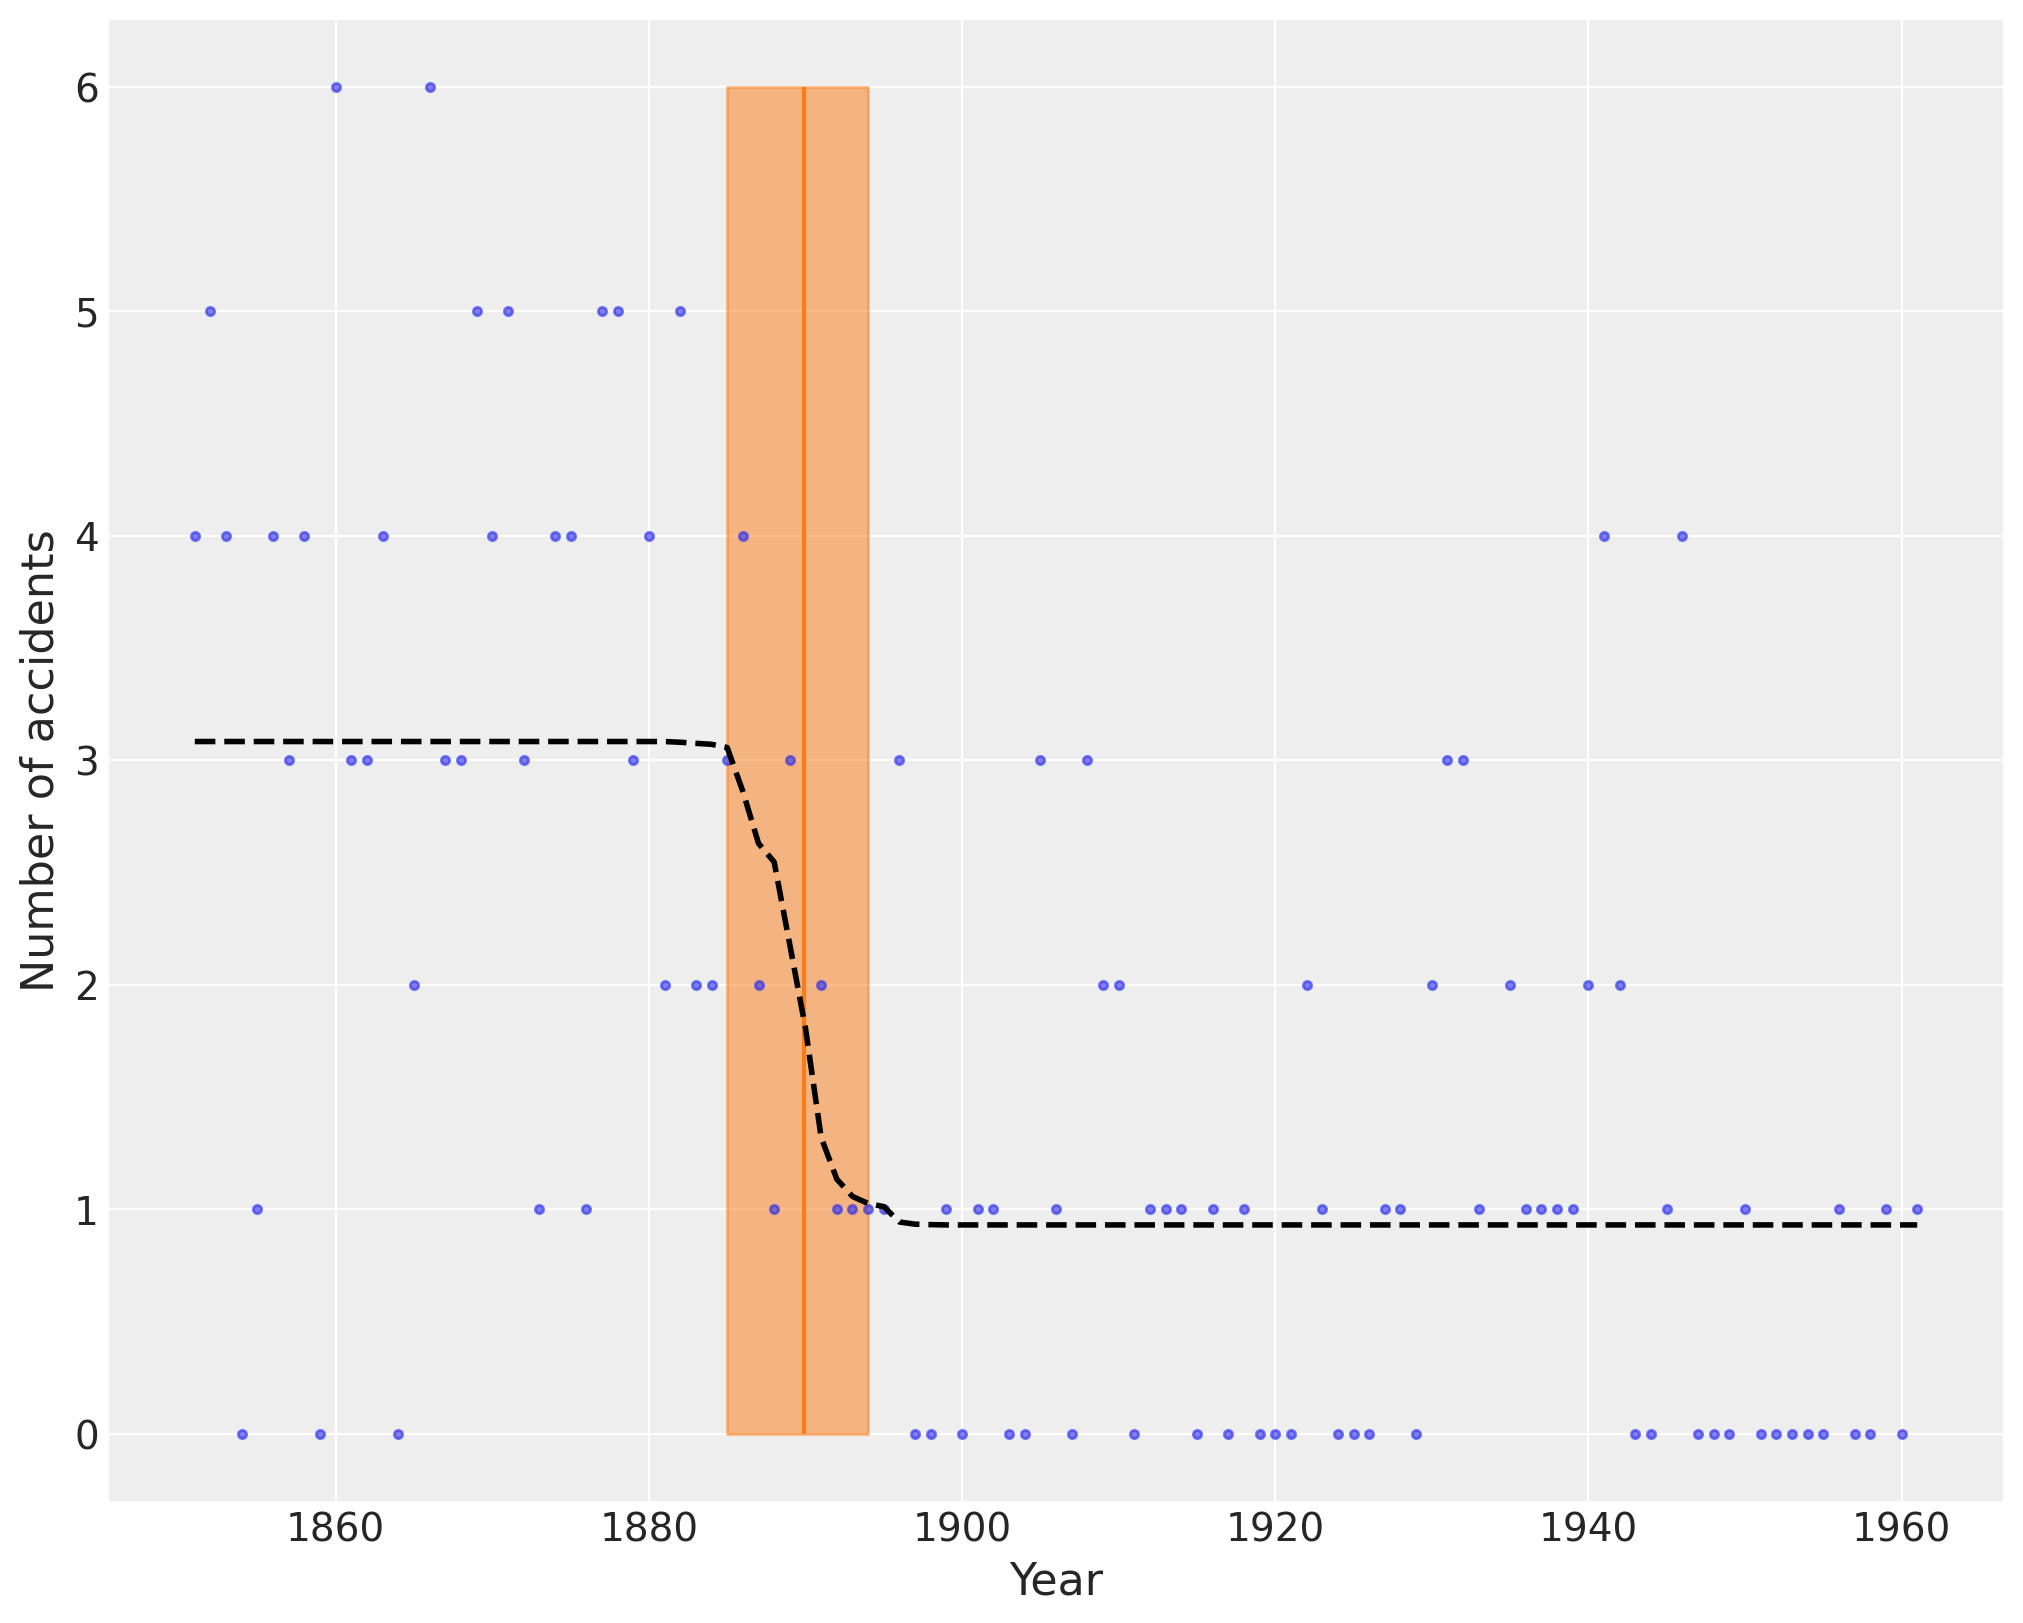

In [21]:
plt.figure(figsize=(10, 8))
plt.plot(years, disaster_data, ".", alpha=0.6)
plt.ylabel("Number of accidents", fontsize=16)
plt.xlabel("Year", fontsize=16)

trace = idata.posterior.stack(draws=("chain", "draw"))

plt.vlines(trace["switchpoint"].mean(), disaster_data.min(), disaster_data.max(), color="C1")
average_disasters = np.zeros_like(disaster_data, dtype="float")
for i, year in enumerate(years):
    idx = year < trace["switchpoint"]
    average_disasters[i] = np.mean(np.where(idx, trace["early_rate"], trace["late_rate"]))

sp_hpd = az.hdi(idata, var_names=["switchpoint"])["switchpoint"].values
plt.fill_betweenx(
    y=[disaster_data.min(), disaster_data.max()],
    x1=sp_hpd[0],
    x2=sp_hpd[1],
    alpha=0.5,
    color="C1",
)
plt.plot(years, average_disasters, "k--", lw=2);

#### Question 5 (optional)
Do some online research: What caused the rate to drop around 1890?

### <font color='green'><u>Solution</u></font>
This could be a possible explanation:
https://en.wikipedia.org/wiki/United_Kingdom_mines_and_quarries_regulation_in_1910

## Part 3
In this last part, you take what you have learnt about probabilistic programming and, specifically, PyMC and apply it to a small problem. This involves both modeling and programming.

#### Question 6
Every day, a store is visited by some customers. Each customer either buys one item, or none at all. The number of customers as well as the number of purchases are recorded for each day. For simplicity, we assume that, on a given day, all customers behave in roughly the same way.

The file `data.txt` contains data for the past 200 days. Propose a way to model this scenario and implement the model using PyMC. Do the chains converge? Create a posterior predictive checking plot by first calling `pm.sample_posterior_predictive(idata)` to sample from the posterior predictive distribution and then feeding the output into `az.plot_ppc`.

In [22]:
import pandas as pd
data = pd.read_csv("data.txt")

### <font color='green'><u>Solution</u></font>
*(The true data was generated using a Poisson process with rate parameter $9.3$, and each customer had a buying probability of $\theta = 0.33$, so that the number of purchases follows $\mathrm{Binom(n,\theta)}$, where $n$ is the number of customers on a given day.)*

Below is a possible way of specifying the model and priors:

In [23]:
with pm.Model() as purchase_model:
    cust_rate = pm.Exponential("cust_rate", 0.5)
    buy_prob = pm.Uniform("buy_prob", lower=0, upper=1)
    customers = pm.Poisson("customers", cust_rate, observed=np.array(data["customers"]))
    buys = pm.Binomial("purchases", n=customers, p=buy_prob, observed=np.array(data["purchases"]))

    idata = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cust_rate, buy_prob]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


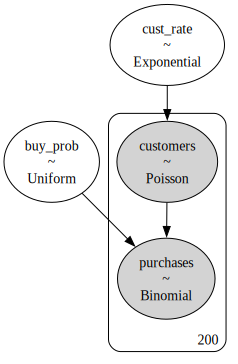

In [25]:
pm.model_to_graphviz(purchase_model)

array([[<Axes: title={'center': 'cust_rate'}>,
        <Axes: title={'center': 'cust_rate'}>],
       [<Axes: title={'center': 'buy_prob'}>,
        <Axes: title={'center': 'buy_prob'}>]], dtype=object)

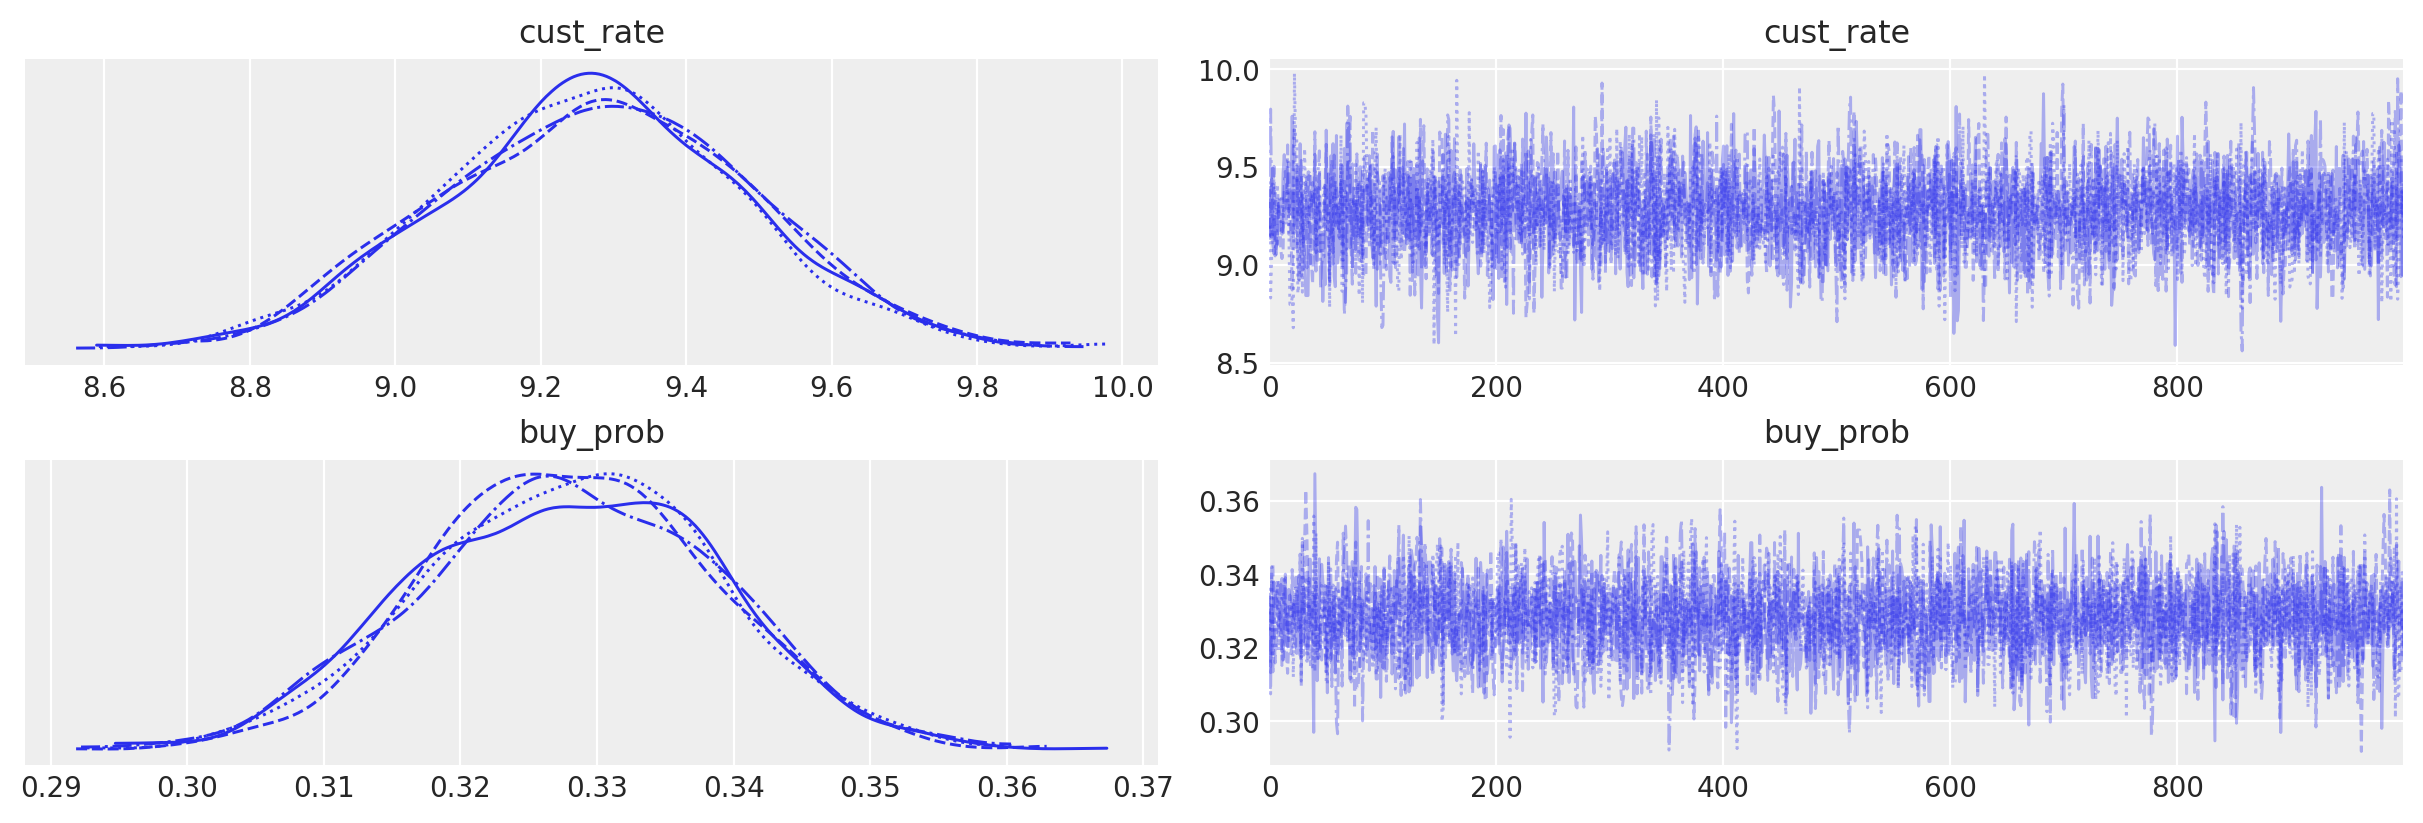

In [23]:
az.plot_trace(idata)

Sampling: [customers, purchases]


Output()

array([<Axes: xlabel='customers'>, <Axes: xlabel='purchases'>],
      dtype=object)

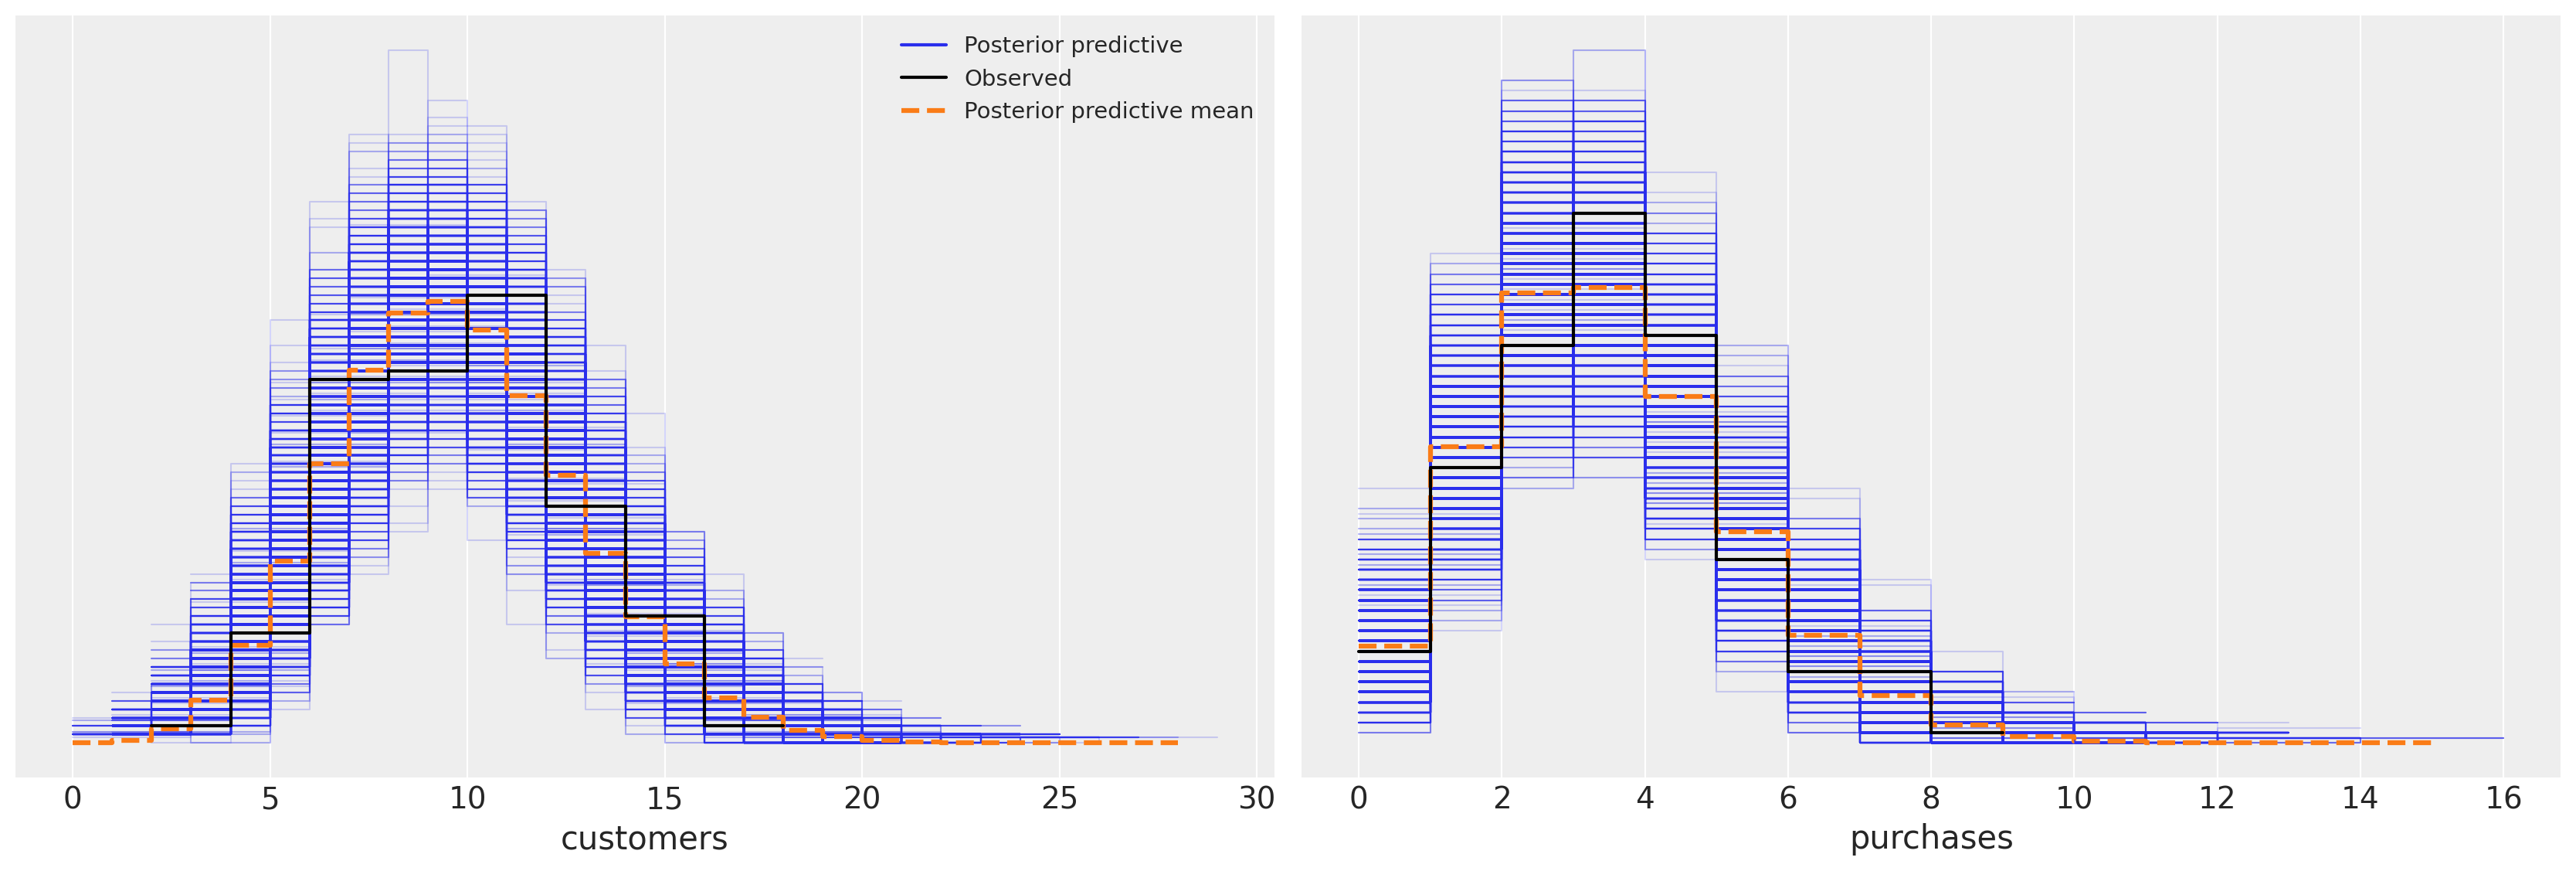

In [26]:
with purchase_model:
    samp = pm.sample_posterior_predictive(idata)
az.plot_ppc(samp)